In [2]:
import os
import cv2
import time
import random
import numpy as np
import glob
import random
import shutil
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split

import torch
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder
import torchvision.transforms as T
import torch.nn as nn
from torchvision.utils import save_image
import torch.nn.functional as F

%matplotlib inline

## GANS

### Generating Covid Images

In [2]:
DATA_DIR = 'Datasets/Complete_Lung_Images/COVID'
print(os.listdir(DATA_DIR))

['COVID']


In [3]:
print(os.listdir(DATA_DIR+'/COVID')[:10])

['COVID-2596.png', 'COVID-317.png', 'COVID-2034.png', 'COVID-2053.png', 'COVID-1442.png', 'COVID-1366.png', 'COVID-1691.png', 'COVID-4.png', 'COVID-770.png', 'COVID-2008.png']


In [4]:
image_size = 64
batch_size = 1
stats = (0.5), (0.5)

In [5]:
train_ds = ImageFolder(DATA_DIR, 
        transform = T.Compose([
            T.Resize(image_size),
            T.ToTensor(),
            T.Normalize(*stats)
        ])
)

train_dl = DataLoader(train_ds, batch_size, shuffle=True, num_workers=3, pin_memory=True)

In [6]:
def denorm(img_tensors):
    return img_tensors * stats[1] + stats[0]

In [7]:
def show_images(images, nmax=10):
    fig, ax = plt.subplots(figsize=(8,8))
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(make_grid(denorm(images.detach()[:nmax]), nrow=8).permute(1,2,0))
    
def show_batch(dl, nmax=64):
    for images, _ in dl:
        show_images(images, nmax)
        break

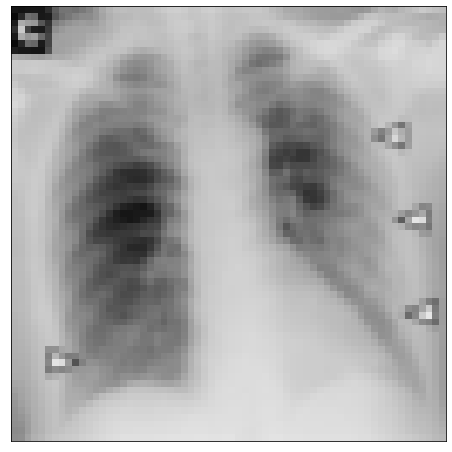

In [8]:
show_batch(train_dl)

In [9]:
def get_default_device():
    """Pick GPU if availabel, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')
    
def to_device(data, device):
    """Move tensor(s) to chosem device"""
    if isinstance(data, (list, tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device
    
    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl:
            yield to_device(b, self.device)
        
    def __len__(self):
        """Number of batches"""
        return len(self.dl)


In [10]:
device = get_default_device()
device

device(type='cuda')

In [12]:
train_dl = DeviceDataLoader(train_dl, device)

In [13]:
discriminator = nn.Sequential(
    
    # in: 3*64*64
    nn.Conv2d(3,64, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(64),
    nn.LeakyReLU(0.2, inplace=True),
    # out: 64*32*32
    
    nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(128),
    nn.LeakyReLU(0.2, inplace=True),
    # out: 128 * 16* 16
    
    nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(256),
    nn.LeakyReLU(0.2, inplace=True),
    # out: 256 * 8* 8
    
    nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(512),
    nn.LeakyReLU(0.2, inplace=True),
    # out: 512 * 4*4
    
    nn.Conv2d(512,1 , kernel_size=4, stride=1, padding=0, bias=False),
    # out: 1*1*1
    
    nn.Flatten(),
    nn.Sigmoid()

)

In [14]:
discriminator = to_device(discriminator, device)

In [15]:
latent_size = 128

In [16]:
generator = nn.Sequential(
    # in: latent_size x 1 x 1

    nn.ConvTranspose2d(latent_size, 512, kernel_size=4, stride=1, padding=0, bias=False),
    nn.BatchNorm2d(512),
    nn.ReLU(True),
    # out: 512 x 4 x 4

    nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(256),
    nn.ReLU(True),
    # out: 256 x 8 x 8

    nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(128),
    nn.ReLU(True),
    # out: 128 x 16 x 16

    nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(True),
    # out: 64 x 32 x 32

    nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1, bias=False),
    nn.Tanh()
    # out: 3 x 64 x 64
)

torch.Size([1, 3, 64, 64])


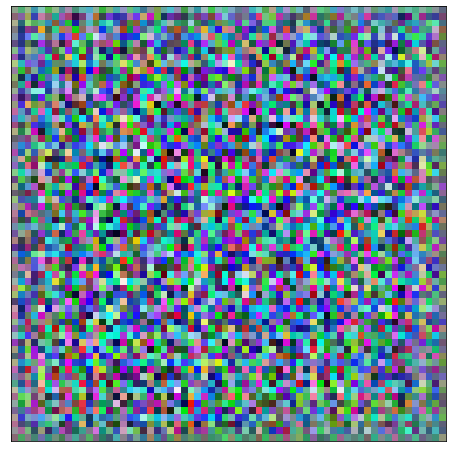

In [17]:
xb = torch.randn(batch_size, latent_size, 1, 1) # random latent tensors
fake_images = generator.forward(xb)
print(fake_images.shape)
show_images(fake_images)

In [18]:
generator = to_device(generator, device)

In [19]:
def train_discriminator(real_images, opt_d):
    # Clear discriminator gradients
    opt_d.zero_grad()
    
    # Pass real images through discriminator
    real_preds = discriminator(real_images)
    real_targets = torch.ones(real_images.size(0), 1, device=device)
    real_loss = F.binary_cross_entropy(real_preds, real_targets)
    real_score = torch.mean(real_preds).item()
    
    # Generate fake images
    latent = torch.randn(batch_size, latent_size, 1,1, device=device)
    fake_images = generator(latent)
    
    # Pass fake images through discriminator
    fake_targets = torch.zeros(fake_images.size(0), 1, device=device)
    fake_preds = discriminator(fake_images)
    fake_loss = F.binary_cross_entropy(fake_preds, fake_targets)
    fake_score = torch.mean(fake_preds).item()
    
    # Update discriminator weights
    loss = real_loss + fake_loss
    loss.backward()
    opt_d.step()
    
    return loss.item(), real_score, fake_score

In [20]:
def train_generator(opt_g):
    # Clear generator gradients
    opt_g.zero_grad()
    
    # Generate fake images
    latent = torch.randn(batch_size, latent_size, 1, 1, device=device)
    fake_images = generator(latent)
    
    # Try to fool the discriminator
    preds = discriminator(fake_images)
    targets = torch.ones(batch_size, 1, device=device)
    loss = F.binary_cross_entropy(preds, targets)
    
    # Update generator weights
    loss.backward()
    opt_g.step()
    
    return loss.item()

In [21]:
sample_dir = 'Generated_Images/Without_Noise_Filter/generated_covid'
os.makedirs(sample_dir, exist_ok=True)

In [22]:
def save_samples(index, latent_tensors, show=True):
    fake_images = generator(latent_tensors)
    fake_fname = 'COVID-{0:0=4d}.png'.format(index)
    save_image(denorm(fake_images), os.path.join(sample_dir, fake_fname), nrow=8)
    print('Saving', fake_fname)
    
    if show:
        fig, ax = plt.subplots(figsize=(8,8))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(fake_images.cpu().detach(), nrow=8).permute(1,2,0))

In [23]:
fixed_latent = torch.randn(1, latent_size, 1, 1, device=device)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Saving COVID-3617.png


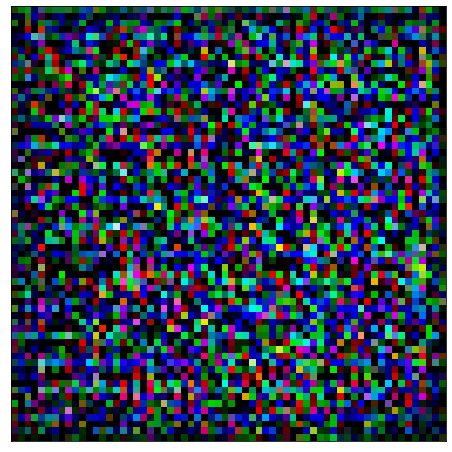

In [24]:
save_samples(3617, fixed_latent)

In [25]:
def fit(epochs, lr, start_idx=1):
    torch.cuda.empty_cache()
    
    # Losses & scores
    losses_g = []
    losses_d = []
    real_scores = []
    fake_scores = []
    
    # Create optimizers
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    s_i = 3718
    
    for epoch in range(epochs):
        for real_images, _ in tqdm(train_dl):
            # Train discriminator
            loss_d, real_score, fake_score = train_discriminator(real_images, opt_d)
            # Train generator
            loss_g = train_generator(opt_g)
            
        # Record losses & scores
        losses_g.append(loss_g)
        losses_d.append(loss_d)
        real_scores.append(real_score)
        fake_scores.append(fake_score)
        
        # Log losses & scores (last batch)
        print("Epoch [{}/{}], loss_g: {:.4f}, loss_d: {:.4f}, real_score: {:.4f}, fake_score: {:.4f}".format(
            epoch+1, epochs, loss_g, loss_d, real_score, fake_score))
    
        # Save generated images
        save_samples(epoch+s_i, fixed_latent, show=False)
    
    return losses_g, losses_d, real_scores, fake_scores

In [26]:
lr = 0.0002
epochs = 50

In [27]:
history = fit(epochs, lr)

  0%|          | 0/3000 [00:00<?, ?it/s]

Epoch [1/50], loss_g: 3.4372, loss_d: 0.5303, real_score: 0.6015, fake_score: 0.0218
Saving COVID-3718.png


  0%|          | 0/3000 [00:00<?, ?it/s]

Epoch [2/50], loss_g: 4.3545, loss_d: 0.3974, real_score: 0.9858, fake_score: 0.3183
Saving COVID-3719.png


  0%|          | 0/3000 [00:00<?, ?it/s]

...

Epoch [48/50], loss_g: 3.8811, loss_d: 0.2433, real_score: 0.8227, fake_score: 0.0470
Saving COVID-3765.png


  0%|          | 0/3000 [00:00<?, ?it/s]

Epoch [49/50], loss_g: 4.4749, loss_d: 0.0356, real_score: 0.9874, fake_score: 0.0227
Saving COVID-3766.png


  0%|          | 0/3000 [00:00<?, ?it/s]

Epoch [50/50], loss_g: 8.5022, loss_d: 0.0010, real_score: 1.0000, fake_score: 0.0010
Saving COVID-3767.png


In [28]:
losses_g, losses_d, real_scores, fake_scores = history

In [29]:
# save the model checkpoints
torch.save(generator.state_dict(), 'G.pth')
torch.save(discriminator.state_dict(), 'D.pth')

In [30]:
from IPython.display import Image

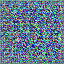

In [31]:
Image('Generated_Images/Without_Noise_Filter/generated_covid/COVID-3617.png')

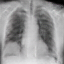

In [32]:
Image('Generated_Images/Without_Noise_Filter/generated_covid/COVID-3640.png')

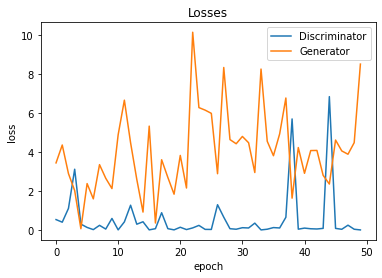

In [33]:
plt.plot(losses_d, '-')
plt.plot(losses_g, '-')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['Discriminator','Generator'])
plt.title('Losses');

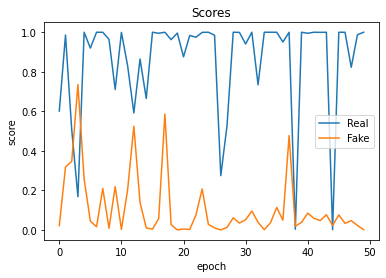

In [34]:
plt.plot(real_scores, '-')
plt.plot(fake_scores, '-')
plt.xlabel('epoch')
plt.ylabel('score')
plt.legend(['Real', 'Fake'])
plt.title('Scores');

In [35]:
# model = torch.load('resnet50_best.pth')


# modeld = discriminator()
# modeld.load_state_dict(torch.load('D.pth'))


latent_size=128

In [36]:
latent = torch.randn(batch_size, latent_size, 1, 1, device=device)
# modelg = generator()

generator.load_state_dict(torch.load('G.pth'))
# discriminator.load_state_dict(torch.load('D.pth'))
# modelg = torch.load('G.pth')
generated_image = generator(latent)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


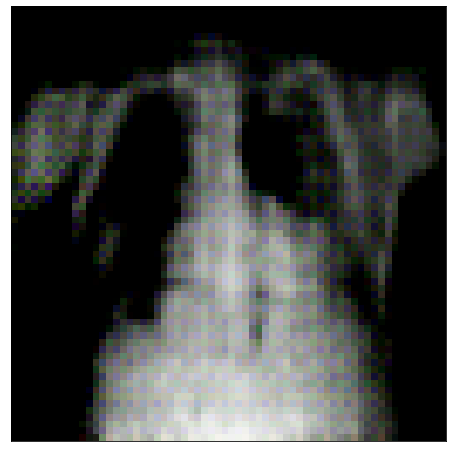

In [38]:
fake_fname = 'COVID-10000.png'.format(10000)
save_image(denorm(generated_image), os.path.join(sample_dir, fake_fname), nrow=8)

fig, ax = plt.subplots(figsize=(8,8))
ax.set_xticks([]); ax.set_yticks([])
ax.imshow(make_grid(generated_image.cpu().detach(), nrow=8).permute(1,2,0))

### Generating Normal Images

In [2]:
DATA_DIR = 'Datasets/Complete_Lung_Images/Normal'
print(os.listdir(DATA_DIR))

['Normal']


In [3]:
print(os.listdir(DATA_DIR+'/Normal')[:10])

['Normal-1623.png', 'Normal-1931.png', 'Normal-2362.png', 'Normal-21.png', 'Normal-2166.png', 'Normal-1297.png', 'Normal-1498.png', 'Normal-1029.png', 'Normal-1063.png', 'Normal-2292.png']


In [4]:
image_size = 64
batch_size = 1
stats = (0.5), (0.5)

In [5]:
train_ds = ImageFolder(DATA_DIR, 
        transform = T.Compose([
            T.Resize(image_size),
            T.ToTensor(),
            T.Normalize(*stats)
        ])
)

train_dl = DataLoader(train_ds, batch_size, shuffle=True, num_workers=3, pin_memory=True)

In [6]:
def denorm(img_tensors):
    return img_tensors * stats[1] + stats[0]

In [7]:
def show_images(images, nmax=10):
    fig, ax = plt.subplots(figsize=(8,8))
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(make_grid(denorm(images.detach()[:nmax]), nrow=8).permute(1,2,0))
    
def show_batch(dl, nmax=64):
    for images, _ in dl:
        show_images(images, nmax)
        break

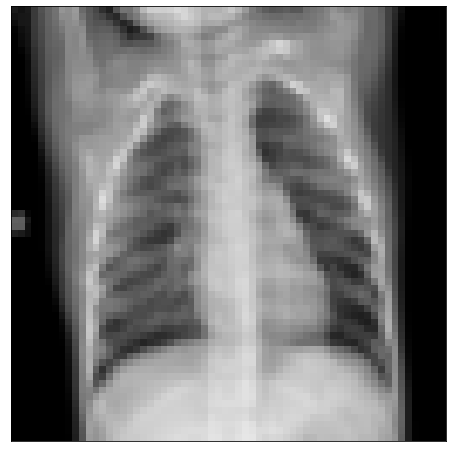

In [8]:
show_batch(train_dl)

In [9]:
def get_default_device():
    """Pick GPU if availabel, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')
    
def to_device(data, device):
    """Move tensor(s) to chosem device"""
    if isinstance(data, (list, tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device
    
    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl:
            yield to_device(b, self.device)
        
    def __len__(self):
        """Number of batches"""
        return len(self.dl)


In [10]:
device = get_default_device()
device

device(type='cuda')

In [11]:
device

device(type='cuda')

In [12]:
train_dl = DeviceDataLoader(train_dl, device)

In [13]:
discriminator = nn.Sequential(
    
    # in: 3*64*64
    nn.Conv2d(3,64, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(64),
    nn.LeakyReLU(0.2, inplace=True),
    # out: 64*32*32
    
    nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(128),
    nn.LeakyReLU(0.2, inplace=True),
    # out: 128 * 16* 16
    
    nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(256),
    nn.LeakyReLU(0.2, inplace=True),
    # out: 256 * 8* 8
    
    nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(512),
    nn.LeakyReLU(0.2, inplace=True),
    # out: 512 * 4*4
    
    nn.Conv2d(512,1 , kernel_size=4, stride=1, padding=0, bias=False),
    # out: 1*1*1
    
    nn.Flatten(),
    nn.Sigmoid()

)

In [14]:
discriminator = to_device(discriminator, device)

In [15]:
latent_size = 128

In [16]:
generator = nn.Sequential(
    # in: latent_size x 1 x 1

    nn.ConvTranspose2d(latent_size, 512, kernel_size=4, stride=1, padding=0, bias=False),
    nn.BatchNorm2d(512),
    nn.ReLU(True),
    # out: 512 x 4 x 4

    nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(256),
    nn.ReLU(True),
    # out: 256 x 8 x 8

    nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(128),
    nn.ReLU(True),
    # out: 128 x 16 x 16

    nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(True),
    # out: 64 x 32 x 32

    nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1, bias=False),
    nn.Tanh()
    # out: 3 x 64 x 64
)

torch.Size([1, 3, 64, 64])


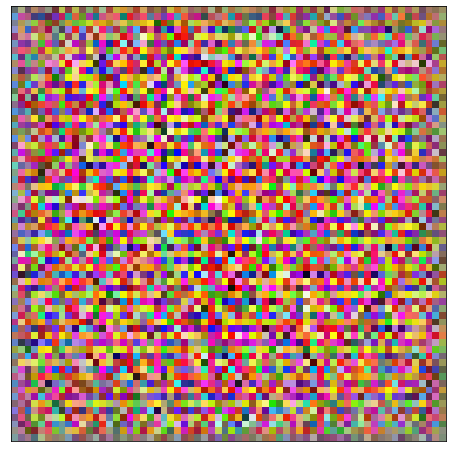

In [17]:
xb = torch.randn(batch_size, latent_size, 1, 1) # random latent tensors
fake_images = generator(xb)
print(fake_images.shape)
show_images(fake_images)

In [18]:
generator = to_device(generator, device)

In [19]:
def train_discriminator(real_images, opt_d):
    # Clear discriminator gradients
    opt_d.zero_grad()
    
    # Pass real images through discriminator
    real_preds = discriminator(real_images)
    real_targets = torch.ones(real_images.size(0), 1, device=device)
    real_loss = F.binary_cross_entropy(real_preds, real_targets)
    real_score = torch.mean(real_preds).item()
    
    # Generate fake images
    latent = torch.randn(batch_size, latent_size, 1,1, device=device)
    fake_images = generator(latent)
    
    # Pass fake images through discriminator
    fake_targets = torch.zeros(fake_images.size(0), 1, device=device)
    fake_preds = discriminator(fake_images)
    fake_loss = F.binary_cross_entropy(fake_preds, fake_targets)
    fake_score = torch.mean(fake_preds).item()
    
    # Update discriminator weights
    loss = real_loss + fake_loss
    loss.backward()
    opt_d.step()
    
    return loss.item(), real_score, fake_score

In [20]:
def train_generator(opt_g):
    # Clear generator gradients
    opt_g.zero_grad()
    
    # Generate fake images
    latent = torch.randn(batch_size, latent_size, 1, 1, device=device)
    fake_images = generator(latent)
    
    # Try to fool the discriminator
    preds = discriminator(fake_images)
    targets = torch.ones(batch_size, 1, device=device)
    loss = F.binary_cross_entropy(preds, targets)
    
    # Update generator weights
    loss.backward()
    opt_g.step()
    
    return loss.item()

In [22]:
sample_dir = 'Generated_Images/Without_Noise_Filter/generated_normal'
os.makedirs(sample_dir, exist_ok=True)

In [23]:
def save_samples(index, latent_tensors, show=True):
    fake_images = generator(latent_tensors)
    fake_fname = 'Normal-{0:0=4d}.png'.format(index)
    save_image(denorm(fake_images), os.path.join(sample_dir, fake_fname), nrow=8)
    print('Saving', fake_fname)
    
    if show:
        fig, ax = plt.subplots(figsize=(8,8))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(fake_images.cpu().detach(), nrow=8).permute(1,2,0))

In [24]:
fixed_latent = torch.randn(1, latent_size, 1, 1, device=device)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Saving Normal-10193.png


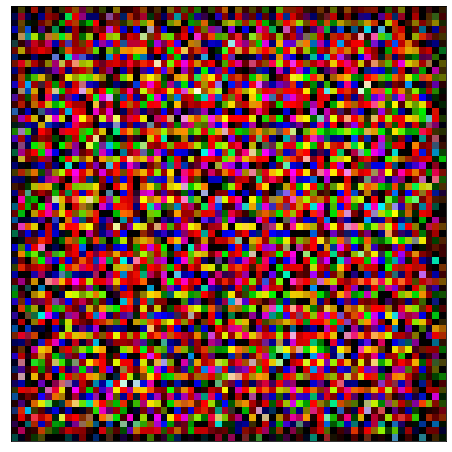

In [25]:
save_samples(10193, fixed_latent)

In [26]:
def fit(epochs, lr, start_idx=1):
    torch.cuda.empty_cache()
    
    # Losses & scores
    losses_g = []
    losses_d = []
    real_scores = []
    fake_scores = []
    
    # Create optimizers
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    s_i = 10286
    
    for epoch in range(epochs):
        for real_images, _ in tqdm(train_dl):
            # Train discriminator
            loss_d, real_score, fake_score = train_discriminator(real_images, opt_d)
            # Train generator
            loss_g = train_generator(opt_g)
            
        # Record losses & scores
        losses_g.append(loss_g)
        losses_d.append(loss_d)
        real_scores.append(real_score)
        fake_scores.append(fake_score)
        
        # Log losses & scores (last batch)
        print("Epoch [{}/{}], loss_g: {:.4f}, loss_d: {:.4f}, real_score: {:.4f}, fake_score: {:.4f}".format(
            epoch+1, epochs, loss_g, loss_d, real_score, fake_score))
    
        # Save generated images
        save_samples(epoch+s_i, fixed_latent, show=False)
    
    return losses_g, losses_d, real_scores, fake_scores

In [27]:
lr = 0.0002
epochs = 50

In [28]:
history = fit(epochs, lr)

  0%|          | 0/3000 [00:00<?, ?it/s]

Epoch [1/50], loss_g: 4.0037, loss_d: 0.0458, real_score: 0.9974, fake_score: 0.0423
Saving Normal-10286.png


  0%|          | 0/3000 [00:00<?, ?it/s]

Epoch [2/50], loss_g: 6.3892, loss_d: 0.0586, real_score: 0.9458, fake_score: 0.0029
Saving Normal-10287.png


  0%|          | 0/3000 [00:00<?, ?it/s]

...

Epoch [48/50], loss_g: 9.5278, loss_d: 0.0002, real_score: 1.0000, fake_score: 0.0002
Saving Normal-10333.png


  0%|          | 0/3000 [00:00<?, ?it/s]

Epoch [49/50], loss_g: 4.5752, loss_d: 0.0190, real_score: 1.0000, fake_score: 0.0189
Saving Normal-10334.png


  0%|          | 0/3000 [00:00<?, ?it/s]

Epoch [50/50], loss_g: 6.7023, loss_d: 0.0276, real_score: 0.9767, fake_score: 0.0040
Saving Normal-10335.png


In [29]:
losses_g, losses_d, real_scores, fake_scores = history

In [30]:
# save the model checkpoints
torch.save(generator.state_dict(), 'G.pth')
torch.save(discriminator.state_dict(), 'D.pth')

In [31]:
from IPython.display import Image

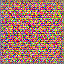

In [32]:
Image('Generated_Images/Without_Noise_Filter/generated_normal/Normal-10193.png')

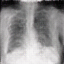

In [33]:
Image('Generated_Images/Without_Noise_Filter/generated_normal/Normal-10221.png')

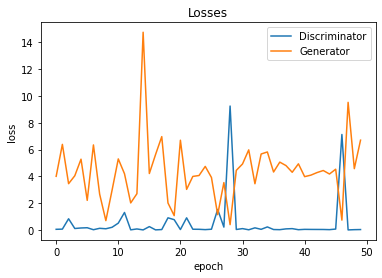

In [34]:
plt.plot(losses_d, '-')
plt.plot(losses_g, '-')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['Discriminator','Generator'])
plt.title('Losses');

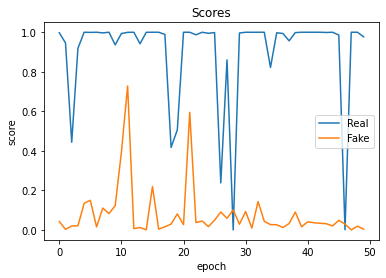

In [35]:
plt.plot(real_scores, '-')
plt.plot(fake_scores, '-')
plt.xlabel('epoch')
plt.ylabel('score')
plt.legend(['Real', 'Fake'])
plt.title('Scores');

## CNN

In [1]:
import os
import cv2
import time
import random
import numpy as np
import glob
import random
import shutil

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
from torchvision.utils import make_grid
from torchvision.models import resnet50

from sklearn.model_selection import train_test_split

from PIL import Image

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
DIR_TRAIN = "Generated_Images/Without_Noise_Filter/Covid_Normal_Images/train/"
DIR_TEST = "Generated_Images/Without_Noise_Filter/Covid_Normal_Images/test/"

In [ ]:
for i in random.sample(glob.glob('Generated_Images/Without_Noise_Filter/Covid_Normal_Images/COVID*'),2000):
    shutil.move(i, 'Generated_Images/Without_Noise_Filter/Covid_Normal_Images/train/')      
for i in random.sample(glob.glob('Generated_Images/Without_Noise_Filter/Covid_Normal_Images/Normal*'), 2000):
    shutil.move(i, 'Generated_Images/Without_Noise_Filter/Covid_Normal_Images/train/')


for i in random.sample(glob.glob('Generated_Images/Without_Noise_Filter/Covid_Normal_Images/COVID*'),1000):
    shutil.move(i, 'Generated_Images/Without_Noise_Filter/Covid_Normal_Images/test/')      
for i in random.sample(glob.glob('Generated_Images/Without_Noise_Filter/Covid_Normal_Images/Normal*'), 1000):
    shutil.move(i, 'Generated_Images/Without_Noise_Filter/Covid_Normal_Images/test/')


In [3]:
imgs = os.listdir(DIR_TRAIN) 
test_imgs = os.listdir(DIR_TEST)

print(imgs[:5])
print(test_imgs[:5])

['COVID-2596.png', 'COVID-317.png', 'COVID-2034.png', 'Normal-1623.png', 'Normal-1931.png']
['COVID-2053.png', 'COVID-1442.png', 'Normal-2362.png', 'COVID-1691.png', 'COVID-1506.png']


In [4]:
covid_list = [img for img in imgs if img.split("-")[0] == "COVID"]
normal_list = [img for img in imgs if img.split("-")[0] == "Normal"]

print("No of Covid Images: ",len(covid_list))
print("No of Normal Images: ",len(normal_list))

class_to_int = {"COVID" : 0, "Normal" : 1}
int_to_class = {0 : "COVID", 1 : "Normal"}

No of Covid Images:  2000
No of Normal Images:  2000


In [5]:
def get_train_transform():
    return T.Compose([
        T.Resize(64),
#         T.CenterCrop(64),
        T.ToTensor(),
        T.Normalize((0.5),(0.5))
    ])
    
def get_val_transform():
    return T.Compose([
        T.ToTensor(),
        T.Normalize((0.5),(0.5))
    ])

In [6]:
class Covid_Normal_Image(Dataset):
    
    def __init__(self, imgs, class_to_int, mode = "train", transforms = None):
        
        super().__init__()
        self.imgs = imgs
        self.class_to_int = class_to_int
        self.mode = mode
        self.transforms = transforms
        
    def __getitem__(self, idx):
        
        image_name = self.imgs[idx]
        
        ### Reading, converting and normalizing image
        #img = cv2.imread(DIR_TRAIN + image_name, cv2.IMREAD_COLOR)
        #img = cv2.resize(img, (224,224))
        #img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
        #img /= 255.
        img = Image.open(DIR_TRAIN + image_name)
        img = img.resize((64, 64))
        
        if self.mode == "train" or self.mode == "val":
        
            ### Preparing class label
            label = self.class_to_int[image_name.split("-")[0]]
            label = torch.tensor(label, dtype = torch.float32)

            ### Apply Transforms on image
            img = self.transforms(img)

            return img, label
        
        elif self.mode == "test":
            
            ### Apply Transforms on image
            img = self.transforms(img)

            return img
            
        
    def __len__(self):
        return len(self.imgs)
    

In [7]:
train_imgs, val_imgs = train_test_split(imgs, test_size = 0.25)

In [8]:
train_dataset = Covid_Normal_Image(train_imgs, class_to_int, mode = "train", transforms = get_train_transform())
val_dataset = Covid_Normal_Image(val_imgs, class_to_int, mode = "val", transforms = get_val_transform())
test_dataset = Covid_Normal_Image(test_imgs, class_to_int, mode = "test", transforms = get_val_transform())

train_data_loader = DataLoader(
    dataset = train_dataset,
#     num_workers = 12,
    batch_size = 1,
    shuffle = True
)

val_data_loader = DataLoader(
    dataset = val_dataset,
#     num_workers = 12,
    batch_size = 1,
    shuffle = True
)

test_data_loader = DataLoader(
    dataset = test_dataset,
#     num_workers = 12,
    batch_size = 1,
    shuffle = True
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


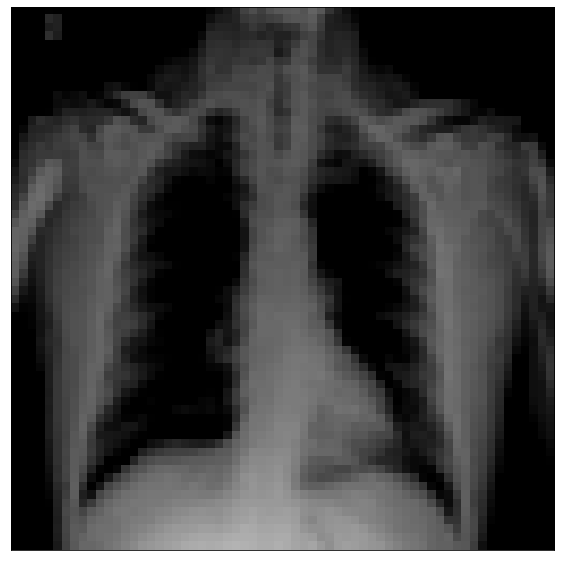

In [9]:
for images, labels in train_data_loader:
    fig, ax = plt.subplots(figsize = (10, 10))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.imshow(make_grid(images, 4).permute(1,2,0))
    break

In [10]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [11]:
def accuracy(preds, trues):
    
    ### Converting preds to 0 or 1
    preds = [1 if preds[i] >= 0.5 else 0 for i in range(len(preds))]
    
    ### Calculating accuracy by comparing predictions with true labels
    acc = [1 if preds[i] == trues[i] else 0 for i in range(len(preds))]
    
    ### Summing over all correct predictions
    acc = np.sum(acc) / len(preds)
    
    return (acc * 100)

In [12]:
def train_one_epoch(train_data_loader):
    
    ### Local Parameters
    epoch_loss = []
    epoch_acc = []
    start_time = time.time()
    
    ###Iterating over data loader
    for images, labels in train_data_loader:
        
        #Loading images and labels to device
        images = images.to(device)
        labels = labels.to(device)
        labels = labels.reshape((labels.shape[0], 1)) # [N, 1] - to match with preds shape
        
        #Reseting Gradients
        optimizer.zero_grad()
        
        #Forward
        preds = model(images)
        
        #Calculating Loss
        _loss = criterion(preds, labels)
        loss = _loss.item()
        epoch_loss.append(loss)
        
        #Calculating Accuracy
        acc = accuracy(preds, labels)
        epoch_acc.append(acc)
        
        #Backward
        _loss.backward()
        optimizer.step()
    
    ###Overall Epoch Results
    end_time = time.time()
    total_time = end_time - start_time
    
    ###Acc and Loss
    epoch_loss = np.mean(epoch_loss)
    epoch_acc = np.mean(epoch_acc)
    
    ###Storing results to logs
    train_logs["loss"].append(epoch_loss)
    train_logs["accuracy"].append(epoch_acc)
    train_logs["time"].append(total_time)
        
    return epoch_loss, epoch_acc, total_time

In [13]:
def val_one_epoch(val_data_loader, best_val_acc):
    
    ### Local Parameters
    epoch_loss = []
    epoch_acc = []
    start_time = time.time()
    
    ###Iterating over data loader
    for images, labels in val_data_loader:
        
        #Loading images and labels to device
        images = images.to(device)
        labels = labels.to(device)
        labels = labels.reshape((labels.shape[0], 1)) # [N, 1] - to match with preds shape
        
        #Forward
        preds = model(images)
        
        #Calculating Loss
        _loss = criterion(preds, labels)
        loss = _loss.item()
        epoch_loss.append(loss)
        
        #Calculating Accuracy
        acc = accuracy(preds, labels)
        epoch_acc.append(acc)
    
    ###Overall Epoch Results
    end_time = time.time()
    total_time = end_time - start_time
    
    ###Acc and Loss
    epoch_loss = np.mean(epoch_loss)
    epoch_acc = np.mean(epoch_acc)
    
    ###Storing results to logs
    val_logs["loss"].append(epoch_loss)
    val_logs["accuracy"].append(epoch_acc)
    val_logs["time"].append(total_time)
    
    ###Saving best model
    if epoch_acc > best_val_acc:
        best_val_acc = epoch_acc
        torch.save(model.state_dict(),"resnet50_best.pth")
        
    return epoch_loss, epoch_acc, total_time, best_val_acc

In [14]:
class Covid_Normal_CNN(nn.Module):
    
    def __init__(self):
        super(Covid_Normal_CNN, self).__init__()
        
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.fc1 = nn.Linear(in_features=8192, out_features=600)
        self.drop = nn.Dropout2d(0.25)
        self.fc2 = nn.Linear(in_features=600, out_features=120)
        self.fc3 = nn.Linear(in_features=120, out_features=1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(out.size(0), -1)
        out = self.fc1(out)
        out = self.drop(out)
        out = self.fc2(out)
        out = self.fc3(out)
        out = self.sigmoid(out)
        
        return out

In [15]:
model = Covid_Normal_CNN()

In [16]:
# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr = 0.0001)

# # Learning Rate Scheduler
# lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size = 5, gamma = 0.5)

#Loss Function
criterion = nn.BCELoss()

# Logs - Helpful for plotting after training finishes
train_logs = {"loss" : [], "accuracy" : [], "time" : []}
val_logs = {"loss" : [], "accuracy" : [], "time" : []}

# Loading model to device
model.to(device)

# No of epochs 
epochs = 15

In [17]:
best_val_acc = 0
for epoch in range(epochs):
    
    ###Training
    loss, acc, _time = train_one_epoch(train_data_loader)
    
    #Print Epoch Details
    print("\nTraining")
    print("Epoch {}".format(epoch+1))
    print("Loss : {}".format(round(loss, 4)))
    print("Acc : {}".format(round(acc, 4)))
    print("Time : {}".format(round(_time, 4)))
    
    ###Validation
    loss, acc, _time, best_val_acc = val_one_epoch(val_data_loader, best_val_acc)
    
    #Print Epoch Details
    print("\nValidating")
    print("Epoch {}".format(epoch+1))
    print("Loss : {}".format(round(loss, 4)))
    print("Acc : {}".format(round(acc, 4)))
    print("Time : {}".format(round(_time, 4)))
    


Training
Epoch 1
Loss : 0.4912
Acc : 77.9333
Time : 21.9646

Validating
Epoch 1
Loss : 0.4182
Acc : 81.4
Time : 3.4979

Training
Epoch 2
Loss : 0.3896
Acc : 82.5333
Time : 21.3281

Validating
Epoch 2
Loss : 0.3423
Acc : 84.4
Time : 3.3962

Training
Epoch 3
Loss : 0.3464
Acc : 84.5667
Time : 21.1891

Validating
Epoch 3
Loss : 0.3336
Acc : 86.3
Time : 3.4001

Training
Epoch 4
Loss : 0.3229
Acc : 86.3667
Time : 21.047

Validating
Epoch 4
Loss : 0.4339
Acc : 80.0
Time : 3.4936

Training
Epoch 5
Loss : 0.293
Acc : 87.5
Time : 20.8491

Validating
Epoch 5
Loss : 0.3776
Acc : 84.4
Time : 3.3788

Training
Epoch 6
Loss : 0.2714
Acc : 87.9333
Time : 20.5349

Validating
Epoch 6
Loss : 0.3363
Acc : 86.2
Time : 3.4851

Training
Epoch 7
Loss : 0.2646
Acc : 88.8667
Time : 21.2871

Validating
Epoch 7
Loss : 0.2721
Acc : 88.2
Time : 3.4258

Training
Epoch 8
Loss : 0.2435
Acc : 89.5
Time : 21.0014

Validating
Epoch 8
Loss : 0.3323
Acc : 85.2
Time : 3.4214

Training
Epoch 9
Loss : 0.2345
Acc : 89.6333
Ti

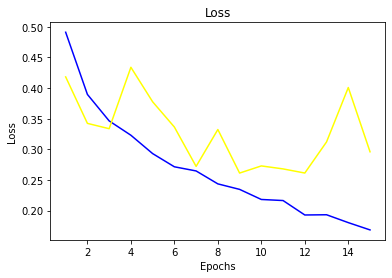

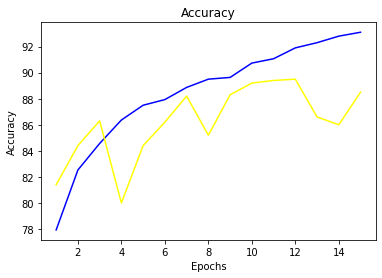

In [18]:
### Plotting Results

#Loss
plt.title("Loss")
plt.plot(np.arange(1, 16, 1), train_logs["loss"], color = 'blue')
plt.plot(np.arange(1, 16, 1), val_logs["loss"], color = 'yellow')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

#Accuracy
plt.title("Accuracy")
plt.plot(np.arange(1, 16, 1), train_logs["accuracy"], color = 'blue')
plt.plot(np.arange(1, 16, 1), val_logs["accuracy"], color = 'yellow')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()